<a href="https://colab.research.google.com/github/saujanyaera/Dog_VS_Cat_Classifier/blob/main/dog_Vs_cat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1 Mount drive
from google.colab import drive
drive.mount('/content/drive')

# 2 Setup kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3 Download dataset
!kaggle datasets download -d tongpython/cat-and-dog

Mounted at /content/drive
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:15<00:00, 14.6MB/s]



In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:00<00:00, 231MB/s]



In [3]:
!unzip cat-and-dog.zip -d datasets

Streaming output truncated to the last 5000 lines.
  inflating: datasets/training_set/training_set/cats/cat.3704.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3705.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3706.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3707.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3708.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3709.jpg  
  inflating: datasets/training_set/training_set/cats/cat.371.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3710.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3711.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3712.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3713.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3714.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3715.jpg  
  inflating: datasets/training_set/training_set/cats/cat.3716.jpg 

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

In [40]:
# generators
train_ds=keras.utils.image_dataset_from_directory(
directory='/content/datasets/training_set/training_set',
labels='inferred',
# labels the images to the numerical values
label_mode='int',
batch_size=32,
# automatically goes to 32 images to the RAM
image_size=(256,256)
)

validation_ds=keras.utils.image_dataset_from_directory(
directory='/content/datasets/test_set/test_set',
labels='inferred',
label_mode='int',
batch_size=32,
image_size=(256,256)
)
class_names = train_ds.class_names
print("Class names:", class_names)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [41]:
# normalization

def process(image, label):
  image=tf.cast(image/255., tf.float32)
  return image, label

train_ds=train_ds.map(process)
# .map processe the function in every images

validation_ds=validation_ds.map(process)



In [7]:
model=Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu',kernel_regularizer=regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid',))
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu',kernel_regularizer=regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
es=EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
from keras.src.backend.torch import optimizers
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# loss and accuracy in trainig data
# val_Accuracy and val_loss in testing data

In [11]:
history=model.fit(train_ds, epochs=20, validation_data=validation_ds, callbacks=[es])

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 127ms/step - accuracy: 0.5437 - loss: 3.4708 - val_accuracy: 0.4998 - val_loss: 5.6763
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.5567 - loss: 2.0046 - val_accuracy: 0.5462 - val_loss: 1.7323
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.5946 - loss: 1.5350 - val_accuracy: 0.6209 - val_loss: 1.3466
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.6279 - loss: 1.3565 - val_accuracy: 0.5724 - val_loss: 1.4006
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.6483 - loss: 1.2287 - val_accuracy: 0.7074 - val_loss: 1.0603
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.7152 - loss: 0.9876 - val_accuracy: 0.6925 - val_loss: 0.9885
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.7527 - loss: 0.8936 - val_accuracy: 0.6807 - val_loss: 0.9614
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.7705 - loss: 0.9477

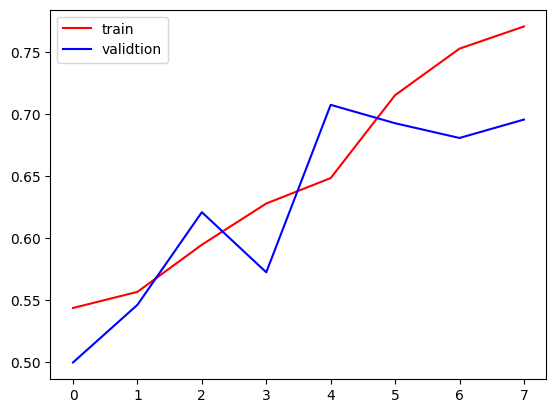

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validtion')
plt.legend()
plt.show()

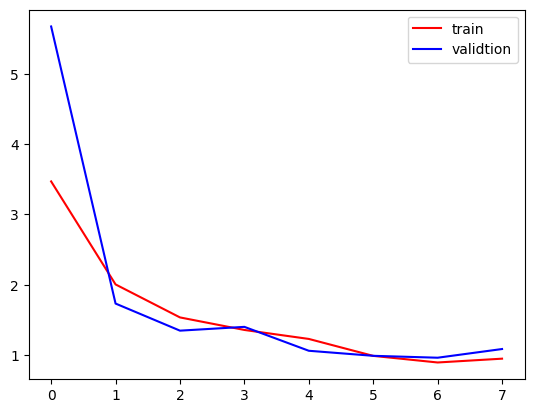

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validtion')
plt.legend()
plt.show()

In [15]:
import cv2



In [66]:
img_test=cv2.imread('/content/dog1.jpg')

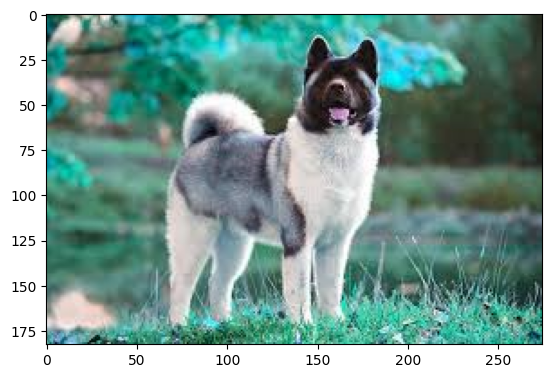

In [67]:
plt.imshow(img_test)

In [29]:
img_test.shape

(625, 863, 3)

In [68]:
img_test=cv2.resize(img_test, (256,256))

In [69]:
test_input=img_test.reshape((1,256,256,3))

In [70]:

pred = model.predict(test_input)
print(pred)
# pred_class = int(pred[0][0] > 0.5)  # 0 or 1
# print("Predicted label:", train_ds.class_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.]]
